## Decision Tree (Cây quyết định)

Đây là một thuật toán supervised learning, có thể giải quyết bài toán Regression và Classification

### Bài toán

Bạn được cung cấp một tập dữ liệu có đặc trưng $\mathbf{X}$ và nhãn tương ứng $\mathbf{y}$, trong đó mỗi điểm dữ liệu $\mathbf{x}_i$ có nhãn là $y_i$.

Mục tiêu là:

> Khi có một điểm dữ liệu mới $\mathbf{x}$, hãy dự đoán nhãn $y$ tương ứng của nó.

#### Ý tưởng: Dùng Decision Tree
Bạn xây dựng một cây quyết định (Decision Tree) từ tập dữ liệu huấn luyện. Cây gồm hai loại node:
- Node quyết định (decision node):  
    - Biểu diễn một feature.  
    - Với bài toán regression, mỗi node còn kèm theo một ngưỡng phân chia.

- Node lá (leaf node):
    - Trả về nhãn (classification) hoặc giá trị (regression).

#### Quy trình xây dựng cây
Quá trình xây dựng cây là một quá trình đệ quy, được thực hiện như sau:

**1. Tại mỗi node:** 

Với mỗi feature $\mathbf{A}$ thực hiện:  

a. Nếu feature là rời rạc (categorical):
Chia dữ liệu theo từng giá trị 
$$
v \in Value(\mathbf{A})
$$

b. Nếu feature là liên tục (numerical):
Tìm các ngưỡng khả dĩ $t$ để chia theo điều kiện:
$$
A \leq t \& A > t
$$

**2. Tính chỉ số đánh giá chất lượng phép chia:**
    - Entropy
    - Gini Index
    - Information Gain (hoặc Gain Ratio)
> Một phép chia tốt là phép chia: Cho ra Information Gain lớn nhất, hoặc Gini/Entropy sau chia là thấp nhất

**3. Chọn ra feature và (nếu cần) ngưỡng chia tốt nhất để tạo node quyết định.**

**4. Chia tập dữ liệu tương ứng với các nhánh con dựa vào phép chia được chọn.**

**5. Gọi đệ quy trên mỗi nhánh để xây cây con.**

**6. Dừng đệ quy khi:**  
- Tất cả các mẫu trong node đều thuộc cùng một nhãn.   
- Hoặc đạt điều kiện dừng như:    
    - Số mẫu nhỏ hơn `min_samples_split`  
    - Độ sâu đạt `max_depth`  
    - Không còn `feature` để chia

### Dự đoán bằng cây:
Khi một điểm mới $\mathbf{x}$ cần được phân loại:
1. Bắt đầu từ gốc cây.  

2. Tại mỗi node quyết định:
    - So sánh giá trị feature tương ứng của $\mathbf{x}$ với điều kiện tại node đó.  
    - Rẽ nhánh trái hoặc phải tương ứng.  

3. Lặp lại cho đến khi đến node lá → đó là kết quả dự đoán.

#### Xây dựng cây tốt
Để cây hoạt động hiệu quả, ta cần đảm bảo mỗi node quyết định chọn ra được một feature tốt nhất để chia dữ liệu.

> Một node quyết định được gọi là tốt nếu nó giúp chia tách các điểm dữ liệu theo nhãn một cách "sạch" nhất có thể.

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
# Load dữ liệu hoa iris
iris = load_iris()
X = iris.data          # ma trận đặc trưng (features)
y = iris.target        # nhãn tương ứng (labels)

In [3]:
# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
# Tạo cây quyết định, có thể dùng criterion='entropy' hoặc 'gini'
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

In [5]:
# Huấn luyện
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
# Dự đoán trên tập test
y_pred = clf.predict(X_test)

In [7]:
# Tính accuracy
acc = accuracy_score(y_test, y_pred)
print("Độ chính xác trên tập test:", acc)

Độ chính xác trên tập test: 1.0


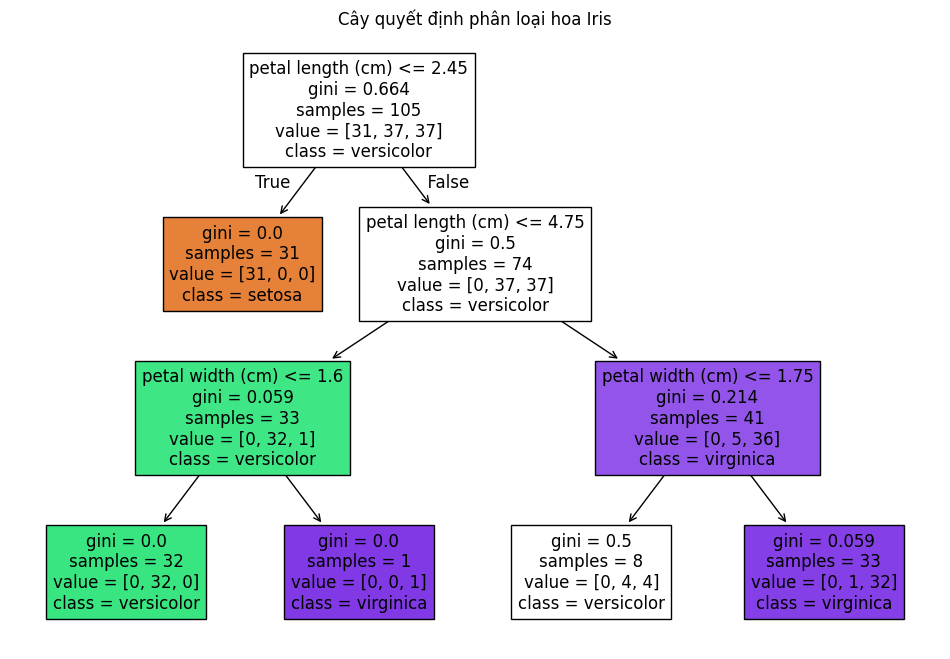

In [8]:
# Cây quyết định
plt.figure(figsize=(12, 8))
plot_tree(clf, 
          filled=True,
          feature_names=iris.feature_names, 
          class_names=iris.target_names)
plt.title("Cây quyết định phân loại hoa Iris")
plt.show()